In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
twitter_file = 'Tweets.csv'
df = pd.read_csv(twitter_file).dropna()
df

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive


In [ ]:
cat_id = {
    'neutral': 1,
    'negative': 0, 
    'positive': 2
}

df['class'] = df['sentiment'].map(cat_id)

In [11]:
X = df['text'].values
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state=123)

print(f"X train: {X_train.shape}, y train: {y_train.shape}\nX test: {X_test.shape}, y test: {y_test.shape}")
print(X_train[0])

X train: (13740,), y train: (13740,)
X test: (13740,), y test: (13740,)
   Oh dear - Boyle is staying ...


In [ ]:
one_hot = CountVectorizer()

X_train_onehot = one_hot.fit_transform(X_train)

X_test_onehot = one_hot.transform(X_test)

print(X_train_onehot.shape)
print(X_train_onehot[0][0])
print()
print(X_train_onehot[1][0])

(13740, 17321)
  (0, 10975)	1
  (0, 4681)	1
  (0, 2861)	1
  (0, 8285)	1
  (0, 14403)	1

  (0, 17047)	1
  (0, 3273)	1
  (0, 10617)	1
  (0, 16440)	1
  (0, 1749)	1
  (0, 10946)	1
  (0, 15162)	1


In [ ]:
print(one_hot.get_feature_names_out())              # 檢查詞彙轉換的list
print(X_train_onehot.toarray()[0][4681])

['00' '000' '000th' ... '½ve' '½you' '½ï']
1


In [14]:
class SentimentData(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = torch.Tensor(X.toarray())
        self.y = torch.Tensor(y).type(torch.LongTensor)         # 轉成長整數
        self.len = len(self.X)
        
    def __len__(self):
        return self.len
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [15]:
BATCH_SIZE = 512

train_ds = SentimentData(X= X_train_onehot, y = y_train)
train_loader = DataLoader(dataset=train_ds, batch_size=BATCH_SIZE, shuffle=True)

test_ds = SentimentData(X_test_onehot, y_test)
test_loader = DataLoader(test_ds, batch_size=15000)

In [20]:
class SentimentModel(nn.Module):
    def __init__(self, NUM_FEATURES, NUM_CLASSES, HIDDEN = 10):
        super().__init__()
        self.linear = nn.Linear(NUM_FEATURES, HIDDEN)
        self.linear2 = nn.Linear(HIDDEN, NUM_CLASSES)
        self.relu = nn.ReLU()
        self.log_softmax = nn.LogSoftmax(dim=1)
        
    def forward(self, x):               # input = (512, 13740, 17321)
        x = self.linear(x)              # output = (512, 13740, 10)
        x = self.relu(x)                # output = (512, 13740, 10)
        x = self.linear2(x)             # output = (512, 13740, 3)
        x = self.log_softmax(x)         # output = (512, 13740, 3)
        return x

In [ ]:
model = SentimentModel(NUM_FEATURES = X_train_onehot.shape[1], NUM_CLASSES = 3)

NUM_EPOCHS = 80

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters())

In [ ]:
train_losses = []

for e in range(NUM_EPOCHS):
    curr_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred_log = model(X_batch)

        loss = criterion(y_pred_log, y_batch.long())
        
        curr_loss += loss.item()

        loss.backward()

        optimizer.step()
        
    train_losses.append(curr_loss)
    print(f"Epoch {e}, Loss: {curr_loss}")

Epoch 0, Loss: 29.99200665950775
Epoch 1, Loss: 28.733837485313416
Epoch 2, Loss: 27.172831654548645
Epoch 3, Loss: 25.39750623703003
Epoch 4, Loss: 23.487346589565277
Epoch 5, Loss: 21.540447890758514
Epoch 6, Loss: 19.654816150665283
Epoch 7, Loss: 17.945922255516052
Epoch 8, Loss: 16.42998641729355
Epoch 9, Loss: 15.11249154806137
Epoch 10, Loss: 13.965296387672424
Epoch 11, Loss: 12.976660281419754
Epoch 12, Loss: 12.095062881708145
Epoch 13, Loss: 11.321254044771194
Epoch 14, Loss: 10.651939779520035
Epoch 15, Loss: 10.034663945436478
Epoch 16, Loss: 9.477207452058792
Epoch 17, Loss: 8.977640330791473
Epoch 18, Loss: 8.532309353351593
Epoch 19, Loss: 8.109240412712097
Epoch 20, Loss: 7.719660073518753
Epoch 21, Loss: 7.366784512996674
Epoch 22, Loss: 7.0471891313791275
Epoch 23, Loss: 6.7453144788742065
Epoch 24, Loss: 6.4581824988126755
Epoch 25, Loss: 6.1973197013139725
Epoch 26, Loss: 5.941505879163742
Epoch 27, Loss: 5.718353658914566
Epoch 28, Loss: 5.502290904521942
Epoch 29

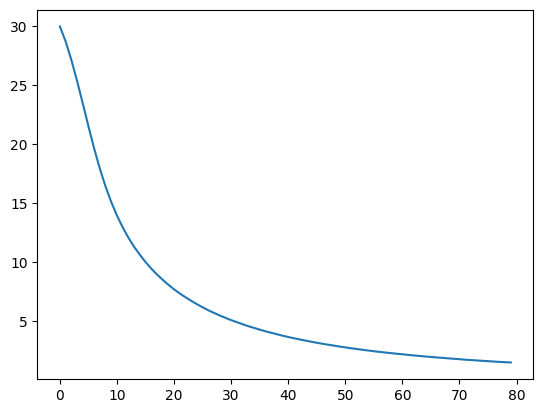

In [23]:
sns.lineplot(x=list(range(len(train_losses))), y= train_losses)
plt.show()

In [24]:
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_test_pred_log = model(X_batch)
        y_test_pred = torch.argmax(y_test_pred_log, dim = 1)

y_test_pred_np = y_test_pred.squeeze().cpu().numpy()

acc = accuracy_score(y_pred=y_test_pred_np, y_true = y_test)
print(f"The accuracy of the model is {np.round(acc, 3)*100}%.")

The accuracy of the model is 64.2%.


In [25]:
most_common_cnt = Counter(y_test).most_common()[0][1]
print(f"Naive Classifier: {np.round(most_common_cnt / len(y_test) * 100, 1)} %")

Naive Classifier: 41.0 %


<Axes: >

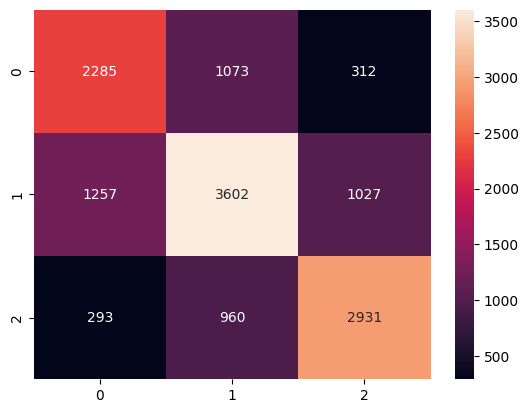

In [26]:
sns.heatmap(confusion_matrix(y_test_pred_np, y_test), annot=True, fmt=".0f")